# Conclusions and Future Work

## Abstract

This project investigates whether deep learning can generate realistic furniture images from sketch-like inputs and whether adversarial training improves the results over reconstruction-only training. Paired inputs and targets were created from bed and dresser photographs in the Bonn Furniture Styles Dataset by extracting Canny edge maps and resizing both images to $256 \times 256$ pixels, producing 14318 paired examples. A reconstruction-only U-Net was compared with a Pix2Pix conditional generative adversarial network evaluated at epochs 20 and 48. Performance was assessed on 2892 unseen test pairs using MAE, PSNR, SSIM, LPIPS and round-trip edge IoU, supported by qualitative inspection, paired statistical tests, effect sizes and structural analysis.

Both approaches generated recognizable furniture images but struggled to recover colour, material and texture information absent from the edge maps. The U-Net performed substantially better on conventional reconstruction metrics, with near-complete rank-based dominance on SSIM over Pix2Pix epoch 48 ($r_{rb}=-0.977$). In contrast, Pix2Pix preserved the conditioning contours much more strongly ($r_{rb}=0.837$ for edge IoU) and produced sharper, more sketch-aligned structures, although it introduced more colour and texture artefacts. The U-Net and Pix2Pix epoch 48 were not statistically distinguishable overall on LPIPS, but exploratory category-level analysis favoured the U-Net for beds and Pix2Pix epoch 48 for dressers. Further Pix2Pix training from epoch 20 to epoch 48 improved the reconstruction and similarity metrics without significantly improving edge IoU. Higher edge density was generally associated with poorer reconstruction and structural scores but with lower LPIPS, suggesting that edge density acted primarily as a proxy for image complexity. Overall, adversarial training did not produce a universal improvement in visual realism; instead, it shifted performance from target-specific reconstruction toward stronger adherence to the input sketch.


## Project Overview and Research Question

This project investigates conditional image-to-image generation of realistic furniture photographs from sketch-like edge maps. It extends the earlier furniture classification project using the same dataset, but changes the task from recognising furniture to generating its visual appearance. The scope is limited to beds and dressers, with Canny edge maps used as conditioning inputs and the corresponding RGB photographs used as targets.

The central research question is: **Can deep learning transform sketch-like furniture edge maps into plausible RGB furniture images, and does adversarial training improve visual realism compared with reconstruction-only learning?** To investigate this, a reconstruction-only U-Net is compared with Pix2Pix, which combines the same generator architecture with adversarial training through a PatchGAN discriminator. This comparison examines whether the adversarial objective improves the generated images and how any improvement differs from accurately reconstructing the specific target photograph.

## Methodology Summary

The project uses beds and dressers from the Bonn Furniture Styles Dataset. After checking image integrity, metadata consistency, duplicates and cross-split leakage, the selected photographs were resized to $256 \times 256$ pixels. Canny edge maps were generated as conditioning inputs and paired with the corresponding RGB photographs as targets, while the cleaned train, validation and test splits were preserved, leaving 14318 usable pairs.

Two training approaches were compared using the same U-Net generator architecture. The reconstruction-only U-Net was optimized using an $L_1$ objective, while Pix2Pix combined $L_1$ reconstruction loss with adversarial training through a PatchGAN discriminator. The best U-Net checkpoint was evaluated against Pix2Pix checkpoints from epochs 20 and 48, allowing both the effect of adversarial training and the later development of the Pix2Pix model to be examined.

Evaluation was performed on 2892 previously unseen test pairs using MAE, PSNR and SSIM for pixel-level reconstruction, LPIPS for perceptual similarity and round-trip edge IoU for contour preservation. The overall results were supported by paired statistical comparisons and effect sizes, followed by per-category, edge-density and qualitative analyses to identify differences that aggregate metrics alone could conceal.

## Results Synthesis

### Training and Overall Performance

The reconstruction-only U-Net exhibited stable convergence under the $L_1$ objective and produced increasingly accurate but generally smooth reconstructions. Pix2Pix training showed the expected adversarial fluctuations, so its generator and discriminator losses could not be interpreted as direct measures of image quality. Nevertheless, both evaluated Pix2Pix checkpoints preserved input contours more strongly than the baseline, while later training from epoch 20 to 48 reduced MAE and LPIPS and increased PSNR and SSIM without producing a statistically significant change in edge IoU.

On the unseen test set, the U-Net achieved lower MAE and higher PSNR and SSIM, demonstrating stronger reconstruction of the specific target photographs. Both Pix2Pix checkpoints achieved substantially higher edge IoU, confirming their greater preservation of the contours supplied by the conditioning sketches. The U-Net and Pix2Pix epoch 48 were statistically indistinguishable on LPIPS overall, although the later per-category analysis showed that this aggregate result concealed opposing differences between beds and dressers. Overall, the results establish a central trade-off between target-specific reconstruction and structural adherence to the input sketch.

### Category and Structural Findings

| Metric | Beds | Dressers |
|---|---|---|
| MAE, PSNR, SSIM | U-Net | U-Net |
| LPIPS | U-Net | Pix2Pix epoch 48 |
| Edge IoU | Pix2Pix | Pix2Pix |

The category-level results preserved the central trade-off, with one exception. LPIPS was category-dependent: the U-Net performed better for beds, whereas Pix2Pix epoch 48 performed better for dressers. These opposing differences explain the statistically indistinguishable overall LPIPS result and show how aggregate metrics can conceal category-specific behaviour.

The structural analysis did not support the initial expectation that sparse sketches would produce the worst quantitative results. Across the evaluated models, greater edge density was associated with higher MAE and lower PSNR, SSIM and edge IoU, while LPIPS decreased, indicating greater similarity according to that metric. Edge density is therefore better interpreted as a proxy for image complexity than as an isolated measure of sketch informativeness: detailed or patterned furniture is harder to reconstruct, while sparse, light-coloured targets can receive favourable pixel scores despite producing visually poor, featureless outputs. Because category and edge density remain partly confounded, these associations should not be interpreted as causal, although the main directional patterns persisted within both categories.

### Qualitative Findings

| Model | Typical qualitative pattern |
|---|---|
| U-Net | Smoother reconstructions, often closer to the target in overall colour and appearance |
| Pix2Pix | Sharper, sketch-aligned contours, but more colour and texture artefacts |
| Both | Appearance details absent from the edge sketch were not consistently recovered |

Pix2Pix frequently imposed brown or orange tones resembling the dominant wood colouring in the training data, supporting the conditional colour prior identified during training analysis. Epoch 20 sometimes appeared qualitatively preferable despite epoch 48 achieving better LPIPS, showing that no single metric fully captures perceived image quality.

### Effect-Size Synthesis

Notebook 05 used paired Wilcoxon signed-rank tests and reported median paired differences, but did not report a standardized effect size. Because those differences retain each metric's original units, their magnitudes cannot be compared directly across metrics. Rank-biserial effect sizes are therefore calculated from the saved paired per-image metrics, without loading the models or generated images again. Their signs are standardized so that positive values favour the second named model and negative values favour the first, accounting for whether higher or lower metric values are preferable. Values near zero indicate little systematic difference, while larger absolute values indicate a stronger effect.

In [1]:
# Setup and Environment
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import rankdata
from google.colab import drive

plt.rcParams["figure.dpi"] = 72

drive.mount("/content/drive")

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Sketch2Furniture"
)
RESULTS_DIR = DRIVE_ROOT / "results"
FIGURE_DIR = DRIVE_ROOT / "figures"
PER_IMAGE_METRICS_PATH = (
    RESULTS_DIR / "per_image_metrics.csv"
)

for required_path in (
    RESULTS_DIR,
    FIGURE_DIR,
    PER_IMAGE_METRICS_PATH,
):
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required path not found: {required_path}"
        )

print(f"Results directory: {RESULTS_DIR}")
print(f"Figure directory: {FIGURE_DIR}")

Mounted at /content/drive
Results directory: /content/drive/MyDrive/Sketch2Furniture/results
Figure directory: /content/drive/MyDrive/Sketch2Furniture/figures


In [2]:
# Calculate Rank-Biserial Effect Sizes


per_image_metrics = pd.read_csv(PER_IMAGE_METRICS_PATH)

EFFECT_COMPARISONS = (
    ("Reconstruction-only U-Net", "Pix2Pix epoch 48"),
    ("Pix2Pix epoch 20", "Pix2Pix epoch 48"),
)
METRIC_HIGHER_IS_BETTER = {
    "mae": False,
    "psnr": True,
    "ssim": True,
    "lpips": False,
    "edge_iou": True,
}


def rank_biserial(differences):
    nonzero = differences[differences != 0]
    ranks = rankdata(np.abs(nonzero))
    positive_sum = ranks[nonzero > 0].sum()
    negative_sum = ranks[nonzero < 0].sum()
    return (positive_sum - negative_sum) / (
        positive_sum + negative_sum
    )


effect_records = []
for model_a, model_b in EFFECT_COMPARISONS:
    for metric_name, higher_is_better in (
        METRIC_HIGHER_IS_BETTER.items()
    ):
        paired = per_image_metrics.pivot(
            index="pair_id",
            columns="model",
            values=metric_name,
        )
        differences = (
            paired[model_b] - paired[model_a]
        ).to_numpy()
        raw_effect = rank_biserial(differences)
        favours_b = raw_effect * (
            1 if higher_is_better else -1
        )
        effect_records.append(
            {
                "comparison": f"{model_a} vs {model_b}",
                "model_a": model_a,
                "model_b": model_b,
                "metric": metric_name,
                "effect_favouring_b": favours_b,
                "favoured_model": (
                    model_b
                    if favours_b > 0
                    else model_a
                    if favours_b < 0
                    else "Neither"
                ),
            }
        )

effect_sizes = pd.DataFrame(effect_records)

EFFECT_SIZES_PATH = (
    RESULTS_DIR / "rank_biserial_effect_sizes.csv"
)
effect_sizes.to_csv(EFFECT_SIZES_PATH, index=False)

display(
    effect_sizes.style.format(
        {"effect_favouring_b": "{:.3f}"}
    )
)
print(f"Saved effect sizes to: {EFFECT_SIZES_PATH}")

,comparison,model_a,model_b,metric,effect_favouring_b,favoured_model
0,Reconstruction-only U-Net vs Pix2Pix epoch 48,Reconstruction-only U-Net,Pix2Pix epoch 48,mae,-0.440,Reconstruction-only U-Net
1,Reconstruction-only U-Net vs Pix2Pix epoch 48,Reconstruction-only U-Net,Pix2Pix epoch 48,psnr,-0.581,Reconstruction-only U-Net
2,Reconstruction-only U-Net vs Pix2Pix epoch 48,Reconstruction-only U-Net,Pix2Pix epoch 48,ssim,-0.977,Reconstruction-only U-Net
3,Reconstruction-only U-Net vs Pix2Pix epoch 48,Reconstruction-only U-Net,Pix2Pix epoch 48,lpips,-0.038,Reconstruction-only U-Net
4,Reconstruction-only U-Net vs Pix2Pix epoch 48,Reconstruction-only U-Net,Pix2Pix epoch 48,edge_iou,0.837,Pix2Pix epoch 48
5,Pix2Pix epoch 20 vs Pix2Pix epoch 48,Pix2Pix epoch 20,Pix2Pix epoch 48,mae,0.224,Pix2Pix epoch 48
6,Pix2Pix epoch 20 vs Pix2Pix epoch 48,Pix2Pix epoch 20,Pix2Pix epoch 48,psnr,0.288,Pix2Pix epoch 48
7,Pix2Pix epoch 20 vs Pix2Pix epoch 48,Pix2Pix epoch 20,Pix2Pix epoch 48,ssim,0.449,Pix2Pix epoch 48
8,Pix2Pix epoch 20 vs Pix2Pix epoch 48,Pix2Pix epoch 20,Pix2Pix epoch 48,lpips,0.148,Pix2Pix epoch 48
9,Pix2Pix epoch 20 vs Pix2Pix epoch 48,Pix2Pix epoch 20,Pix2Pix epoch 48,edge_iou,-0.002,Pix2Pix epoch 20


Saved effect sizes to: /content/drive/MyDrive/Sketch2Furniture/results/rank_biserial_effect_sizes.csv


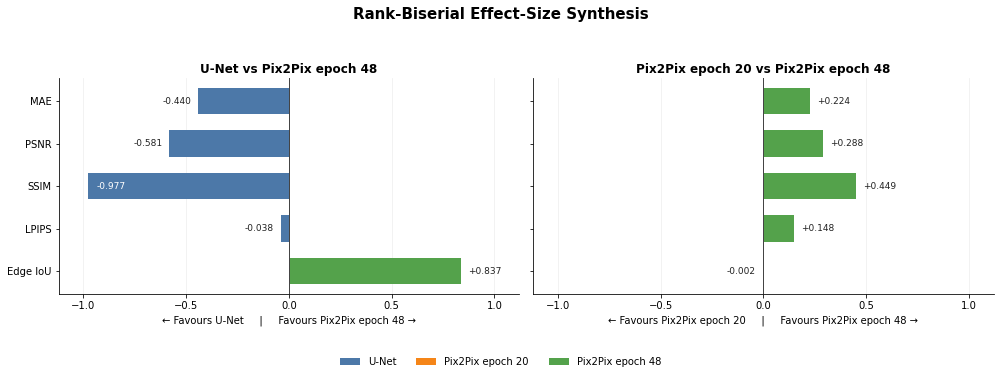

Saved figure to: /content/drive/MyDrive/Sketch2Furniture/figures/rank_biserial_effect_size_synthesis.png


In [4]:
from matplotlib.patches import Patch

METRIC_ORDER = [
    "mae",
    "psnr",
    "ssim",
    "lpips",
    "edge_iou",
]

METRIC_LABELS = {
    "mae": "MAE",
    "psnr": "PSNR",
    "ssim": "SSIM",
    "lpips": "LPIPS",
    "edge_iou": "Edge IoU",
}

MODEL_LABELS = {
    "Reconstruction-only U-Net": "U-Net",
    "Pix2Pix epoch 20": "Pix2Pix epoch 20",
    "Pix2Pix epoch 48": "Pix2Pix epoch 48",
}

MODEL_COLOURS = {
    "Reconstruction-only U-Net": "#4C78A8",
    "Pix2Pix epoch 20": "#F58518",
    "Pix2Pix epoch 48": "#54A24B",
}

PLOT_COMPARISONS = [
    ("Reconstruction-only U-Net", "Pix2Pix epoch 48"),
    ("Pix2Pix epoch 20", "Pix2Pix epoch 48"),
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.2),
    sharey=True,
)

y_positions = np.arange(len(METRIC_ORDER))

for ax, (model_a, model_b) in zip(
    axes,
    PLOT_COMPARISONS,
):
    panel_data = (
        effect_sizes[
            (effect_sizes["model_a"] == model_a)
            & (effect_sizes["model_b"] == model_b)
        ]
        .set_index("metric")
        .loc[METRIC_ORDER]
        .reset_index()
    )

    values = panel_data[
        "effect_favouring_b"
    ].to_numpy()

    colours = [
        MODEL_COLOURS.get(model, "#9E9E9E")
        for model in panel_data["favoured_model"]
    ]

    ax.barh(
        y_positions,
        values,
        color=colours,
        height=0.62,
    )

    ax.axvline(
        0,
        color="#444444",
        linewidth=1,
    )

    ax.set_xlim(-1.12, 1.12)
    ax.set_xticks(
        [-1.0, -0.5, 0.0, 0.5, 1.0]
    )
    ax.grid(
        axis="x",
        alpha=0.2,
    )
    ax.set_axisbelow(True)

    ax.set_title(
        f"{MODEL_LABELS[model_a]} vs "
        f"{MODEL_LABELS[model_b]}",
        fontweight="bold",
    )

    ax.set_xlabel(
        f"← Favours {MODEL_LABELS[model_a]}"
        f"     |     "
        f"Favours {MODEL_LABELS[model_b]} →"
    )

    for y_position, value in zip(y_positions, values):
        if abs(value) >= 0.9:
            offset = (-0.04 if value > 0 else 0.04)
            alignment = ("right" if value > 0 else "left")
            text_colour = "white"
        else:
            offset = (0.035 if value >= 0 else -0.035)
            alignment = ("left" if value >= 0 else "right")
            text_colour = "#222222"

        ax.text(
            value + offset,
            y_position,
            f"{value:+.3f}",
            va="center",
            ha=alignment,
            fontsize=9,
            color=text_colour,
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_yticks(
    y_positions,
    [
        METRIC_LABELS[metric]
        for metric in METRIC_ORDER
    ],
)
axes[0].invert_yaxis()

legend_handles = [
    Patch(
        facecolor=colour,
        label=MODEL_LABELS[model],
    )
    for model, colour in MODEL_COLOURS.items()
]

fig.suptitle(
    "Rank-Biserial Effect-Size Synthesis",
    fontsize=15,
    fontweight="bold",
)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=False,
)

fig.tight_layout(rect=[0, 0.10, 1, 0.93])

EFFECT_SIZE_FIGURE_PATH = (
    FIGURE_DIR
    / "rank_biserial_effect_size_synthesis.png"
)

fig.savefig(
    EFFECT_SIZE_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure to: "
    f"{EFFECT_SIZE_FIGURE_PATH}"
)

The standardized effects quantify the central trade-off between the two training approaches. SSIM showed near-complete rank-based dominance by the U-Net ($r_{rb}=-0.977$), whereas edge IoU strongly favoured Pix2Pix epoch 48 ($r_{rb}=0.837$). Compared with epoch 20, epoch 48 improved all four reconstruction and similarity metrics, most strongly SSIM, while its effect on edge IoU was effectively zero ($r_{rb}=-0.002$). The overall LPIPS difference between the U-Net and Pix2Pix epoch 48 was also negligible ($r_{rb}=-0.038$). Both near-zero effects corresponded to comparisons that were not statistically significant, showing agreement between the effect sizes and paired tests.


## Answer to the Research Question

The results answer the research question in two parts. First, deep learning can transform sketch-like furniture edge maps into recognizable and plausible RGB images, although neither approach consistently recovered colour and texture details absent from the input sketch. Second, adversarial training did not produce a universal improvement in visual realism. Instead, it shifted performance from target-specific reconstruction toward structural adherence: the U-Net performed substantially better on MAE, PSNR and SSIM, most strongly on SSIM ($r_{rb}=-0.977$), while Pix2Pix preserved the conditioning contours much more strongly ($r_{rb}=0.837$ for edge IoU) and produced sharper, sketch-aligned structures, but also introduced more colour and texture artefacts.

On LPIPS, a learned metric designed to approximate perceptual similarity, the U-Net and Pix2Pix epoch 48 were not statistically distinguishable overall. However, this aggregate result concealed opposing category effects: the U-Net performed better for beds, whereas Pix2Pix epoch 48 performed better for dressers. Any advantage from adversarial training according to LPIPS therefore depends on the furniture category rather than applying generally.

Further Pix2Pix training from epoch 20 to epoch 48 improved MAE, PSNR, SSIM and LPIPS, but did not significantly improve edge IoU, and epoch 20 was sometimes preferred qualitatively. The most suitable approach therefore depends on the objective: the reconstruction-only U-Net is preferable when similarity to the specific target photograph is the priority, whereas Pix2Pix is preferable when adherence to the input sketch is more important. Overall, adversarial training improved structural fidelity, but the evidence does not support an across-the-board improvement in visual realism.


## Limitations


* **Restricted dataset scope.** The evaluation included only beds and dressers from a single furniture dataset, consisting mainly of isolated product photographs. The findings may not generalize to other furniture categories, complex backgrounds or different image domains.

* **Undetected category errors.** Manual inspection identified `pair_02860`, which was filed under `beds` but lacks recognizable bed features and resembles a low table. Because its filename descriptor, `toddler-beds`, appeared category-consistent, the filename-based cleaning in Notebook 01 could not detect the error. The number of similar miscategorized records is therefore unknown.

* **Residual duplicate risk.** Exact duplicates and visually confirmed cross-split near-duplicates were removed, but unconfirmed perceptual-hash candidates were retained to avoid discarding valid images. Some visually similar pairs may therefore remain across splits.

* **Edge maps rather than human sketches.** The inputs were Canny edges extracted directly from the target photographs, preserving their geometry and alignment. Freehand sketches may be incomplete, distorted or stylistically variable, making real sketch-to-image generation more difficult.

* **Ambiguous reconstruction target.** An edge map does not specify a unique colour, material or texture, although the full-reference metrics compare each output with one particular photograph. Plausible alternatives may therefore receive poor scores, while featureless outputs can score favourably for light or simple targets.

* **Contour metric sensitivity.** Round-trip edge IoU can reward agreement on a small number of contours, so a high value for a sparse sketch does not imply successful image reconstruction. In one diagnostic example, the metric reached 0.892 despite the generated image being nearly featureless.

* **Incomplete measurement of realism.** MAE, PSNR, SSIM, LPIPS and edge IoU capture complementary properties but do not fully represent human judgements of realism. The qualitative analysis partially addressed this limitation but used selected examples rather than a formal perceptual study. In addition, the per-category LPIPS tests were motivated by an observed pattern rather than pre-specified, so their results should be treated as exploratory.

* **Limited experimental replication.** Each training approach was evaluated from a single run under one configuration, without repeated random seeds or an extensive hyperparameter search. The discriminator’s training loss also approached zero while its validation loss rose, indicating an adversarial imbalance that may have influenced Pix2Pix training. The conclusions therefore apply to the evaluated runs and checkpoints rather than all possible training conditions.

* **Observational structural analysis.** Edge density was associated with model performance but was also related to category and image complexity. Although the main directional patterns persisted within both categories, the correlations should not be interpreted as causal.


## Future Work

The limitations identified above suggest several directions for extending this project. Future studies could test whether the observed trade-off between target-image reconstruction and contour adherence persists across additional furniture categories, repeated training runs and real freehand sketches. Broader perceptual and structural evaluation could establish whether the category-dependent LPIPS findings correspond to human judgements, while further model development could investigate whether reconstruction quality and structural fidelity can be balanced more effectively.

One limitation cannot be addressed through training alone. A binary edge map does not explicitly encode colour, material or texture, so the generator must infer these properties from patterns learned in the training data. Providing an additional conditioning signal, such as a colour hint or the furniture style label already present in the metadata, would allow aspects of the desired appearance to be specified rather than inferred.

This Deep Learning project represents Phase 2 of a broader three-phase plan, following the classical machine-learning classification developed in Phase 1. Phase 3 is planned as an interactive demonstration in which users can draw or upload furniture sketches and receive category predictions or generated realistic concepts. In addition to providing a practical application of the two projects, the demonstration would test the generative models under the freehand input conditions that real users would provide.


## References

### Dataset

Aggarwal, D., Valiyev, E., Sener, F., & Yao, A. (2018). Learning style compatibility for furniture. In German Conference on Pattern Recognition (GCPR), 552–566. Springer. arXiv:1812.03570.

### Computer Vision and Image Processing

Canny, J. (1986). A computational approach to edge detection. IEEE Transactions on Pattern Analysis and Machine Intelligence, 8(6), 679–698.

### Models and Training

Isola, P., Zhu, J.-Y., Zhou, T., & Efros, A. A. (2017). Image-to-image translation with conditional adversarial networks. In IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 1125–1134.

Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional networks for biomedical image segmentation. In Medical Image Computing and Computer-Assisted Intervention (MICCAI), 234–241. Springer.

Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. In International Conference on Learning Representations (ICLR).

### Evaluation Metrics

Wang, Z., Bovik, A. C., Sheikh, H. R., & Simoncelli, E. P. (2004). Image quality assessment: From error visibility to structural similarity. IEEE Transactions on Image Processing, 13(4), 600–612.

Zhang, R., Isola, P., Efros, A. A., Shechtman, E., & Wang, O. (2018). The unreasonable effectiveness of deep features as a perceptual metric. In IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 586–595.

### Statistical Methods

Spearman, C. (1904). The proof and measurement of association between two things. The American Journal of Psychology, 15(1), 72–101.

Wilcoxon, F. (1945). Individual comparisons by ranking methods. Biometrics Bulletin, 1(6), 80–83.

Holm, S. (1979). A simple sequentially rejective multiple test procedure. Scandinavian Journal of Statistics, 6(2), 65–70.

Kerby, D. S. (2014). The simple difference formula: An approach to teaching nonparametric correlation. Comprehensive Psychology, 3, 11.IT.3.1.

### Software

Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., Killeen, T., Lin, Z., Gimelshein, N., Antiga, L., Desmaison, A., Köpf, A., Yang, E., DeVito, Z., Raison, M., Tejani, A., Chilamkurthy, S., Steiner, B., Fang, L., Bai, J., & Chintala, S. (2019). PyTorch: An imperative style, high-performance deep learning library. Advances in Neural Information Processing Systems, 32, 8024–8035.

Detlefsen, N. S., Borovec, J., Schock, J., Jha, A. H., Koker, T., Di Liello, L., Stancl, D., Quan, C., Grechkin, M., & Falcon, W. (2022). TorchMetrics - Measuring reproducibility in PyTorch. Journal of Open Source Software, 7(70), 4101.

Bradski, G. (2000). The OpenCV library. Dr. Dobb's Journal, 25(11), 120–125.

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C., & Oliphant, T. E. (2020). Array programming with NumPy. Nature, 585, 357–362.

Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., Carey, C. J., Polat, İ., Feng, Y., Moore, E. W., VanderPlas, J., Laxalde, D., Perktold, J., Cimrman, R., Henriksen, I., Quintero, E. A., Harris, C. R., Archibald, A. M., Ribeiro, A. H., Pedregosa, F., van Mulbregt, P., & SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. Nature Methods, 17, 261–272.

Seabold, S., & Perktold, J. (2010). statsmodels: Econometric and statistical modeling with Python. Proceedings of the 9th Python in Science Conference, 92–96.

McKinney, W. (2010). Data structures for statistical computing in Python. Proceedings of the 9th Python in Science Conference, 56–61.

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90–95.

Waskom, M. L. (2021). seaborn: statistical data visualization. Journal of Open Source Software, 6(60), 3021.

### Course Materials

Darakchiev, Y. (2026). Deep Learning [Course materials]. Software University (SoftUni).

### Acknowledgments
This project was developed with the assistance of Claude (Anthropic).


---

$$\text{Sketch2Furniture}$$

$$\blacksquare$$